In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from pymargins import Margins

rng = np.random.default_rng(11)
n = 3000
df = pd.DataFrame({
    "age": rng.integers(20, 75, n),
    "female": rng.binomial(1, 0.5, n),
    "education": rng.choice(["hs", "college", "grad"], size=n, p=[.5, .35, .15]),
})
df["wage"] = (
    10 + 0.3 * df["age"] - 2.0 * df["female"]
    + 4 * (df["education"] == "college") + 8 * (df["education"] == "grad")
    + rng.normal(0, 5, n)
)

fit = smf.ols("wage ~ age + C(female) + C(education) + age:C(female)",
              data=df).fit()

In [2]:
m = Margins.linear_scale(fit, vcov="HC2", at="overall")
print(m.dydx("age").summary())

            Margins Result (delta, level=0.95)           
     estimate  std err         z  P>|z|  [95% Conf. Int.]
---------------------------------------------------------
age    0.3000   0.0004  713.9780  0.000    0.2992, 0.3008

n = 3000
κ: 0.000
Delta-vs-sim disagreement: 4.218%


In [3]:
print(m.dydx("age", atexog={"female": [0, 1]}).summary())

                 Margins Result (delta, level=0.95)                
                    estimate  std err    z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------------
female=[0, 1], age    0.2998   0.0002  inf  0.000    0.2994, 0.3002

n = 3000
κ: 0.000
Delta-vs-sim disagreement: 4.134%


In [4]:
print(m.predict(atexog={"education": ["hs", "college", "grad"]}).summary())

                   Margins Result (delta, level=0.95)                  
                   estimate  std err         z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------------------
education=hs        23.1750   0.1279  181.2105  0.000  22.9244, 23.4257
education=college   26.8908   0.1539  174.7156  0.000  26.5892, 27.1925
education=grad      31.1735   0.2514  124.0111  0.000  30.6808, 31.6662

n = 3000
κ: max=0.000
Delta-vs-sim disagreement: 0.092%


[Text(0.5, 0, 'Education'), Text(0, 0.5, 'Predicted wage')]

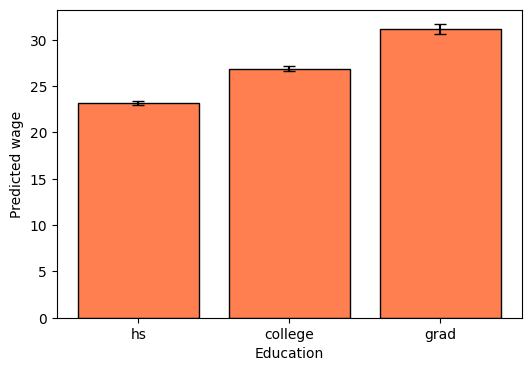

In [5]:
import matplotlib.pyplot as plt

res = m.predict(atexog={"education": ["hs", "college", "grad"]})
df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df_plot["education"], df_plot["estimate"],
       yerr=[df_plot["estimate"] - df_plot["ci_lower"],
             df_plot["ci_upper"] - df_plot["estimate"]],
       capsize=4, color="coral", edgecolor="black")
ax.set(xlabel="Education", ylabel="Predicted wage")

In [6]:
from pymargins import pairwise

scen, w = pairwise("education", ["grad", "hs"])
print(m.contrasts(scenarios=scen, contrasts=w).summary())

                 Margins Result (delta, level=0.95)                
                estimate  std err        z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------------
education=grad    7.9984   0.2820  28.3607  0.000    7.4457, 8.5512

n = 3000
κ: 0.000
Delta-vs-sim disagreement: 0.213%
